In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from surprise import SVD, Dataset, Reader
from surprise.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

print("All imports successful ✅")

All imports successful ✅


In [2]:
ratings = pd.read_csv("../../Data/raw/ratings.csv")
movies  = pd.read_csv("../../Data/raw/movies.csv")

print(f"Ratings : {ratings.shape}")
print(f"Movies  : {movies.shape}")

Ratings : (100836, 4)
Movies  : (9742, 3)


In [12]:
# Load SVD model from Step 3
svd_model     = joblib.load("../../backend/saved_models/svd_model.pkl")

# Load content-based models from Step 4
cosine_sim    = joblib.load("../../backend/saved_models/cosine_sim.pkl")
movie_indices = joblib.load("../../backend/saved_models/movie_indices.pkl")
tfidf_matrix  = joblib.load("../../backend/saved_models/tfidf_matrix.pkl")

print("SVD model loaded     ✅")
print("Cosine sim loaded    ✅")
print("Movie indices loaded ✅")
print("TF-IDF matrix loaded ✅")

SVD model loaded     ✅
Cosine sim loaded    ✅
Movie indices loaded ✅
TF-IDF matrix loaded ✅


In [13]:
reader   = Reader(rating_scale=(0.5, 5.0))
data     = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

print("Surprise dataset ready ✅")

Surprise dataset ready ✅


In [14]:
def get_collaborative_scores(user_id, movies_df, ratings_df, svd_model):
    """
    For a given user, predict SVD rating for every unrated movie.
    Returns a DataFrame with movieId and predicted rating.
    """
    # Movies user already rated
    rated = ratings_df[ratings_df['userId'] == user_id]['movieId'].tolist()

    # Predict for all unrated movies
    predictions = []
    for _, row in movies_df.iterrows():
        movie_id = row['movieId']
        if movie_id not in rated:
            pred = svd_model.predict(user_id, movie_id).est
            predictions.append({
                'movieId'     : movie_id,
                'title'       : row['title'],
                'collab_score': pred
            })

    return pd.DataFrame(predictions)


# Test it
collab_scores = get_collaborative_scores(
    user_id    = 1,
    movies_df  = movies,
    ratings_df = ratings,
    svd_model  = svd_model
)

print(f"Collaborative scores computed for {len(collab_scores)} movies")
print(collab_scores.head())

Collaborative scores computed for 9510 movies
   movieId                               title  collab_score
0        2                      Jumanji (1995)      4.370033
1        4            Waiting to Exhale (1995)      3.803139
2        5  Father of the Bride Part II (1995)      3.705451
3        7                      Sabrina (1995)      4.158430
4        8                 Tom and Huck (1995)      4.244582


In [15]:
def get_content_scores(user_id, movies_df, ratings_df, cosine_sim, movie_indices):
    """
    For a given user, compute content similarity score for every movie
    based on their highly rated movies.
    """
    # Movies user liked (rated 4.0+)
    liked = (ratings_df[
        (ratings_df['userId'] == user_id) &
        (ratings_df['rating'] >= 4.0)
    ].merge(movies_df, on='movieId')['title'].tolist())

    # Movies user already watched
    watched_ids = ratings_df[ratings_df['userId'] == user_id]['movieId'].tolist()

    # Accumulate content scores from each liked movie
    content_scores = {}

    for liked_title in liked:
        if liked_title not in movie_indices:
            continue
        idx        = movie_indices[liked_title]
        sim_scores = list(enumerate(cosine_sim[idx]))

        for movie_idx, score in sim_scores:
            movie_id = movies_df.iloc[movie_idx]['movieId']
            if movie_id in watched_ids:
                continue
            if movie_id not in content_scores:
                content_scores[movie_id] = score
            else:
                content_scores[movie_id] = max(content_scores[movie_id], score)

    # Convert to DataFrame
    result = pd.DataFrame(
        content_scores.items(),
        columns=['movieId', 'content_score']
    )

    return result


# Test it
content_scores = get_content_scores(
    user_id       = 1,
    movies_df     = movies,
    ratings_df    = ratings,
    cosine_sim    = cosine_sim,
    movie_indices = movie_indices
)

print(f"Content scores computed for {len(content_scores)} movies")
print(content_scores.head())

Content scores computed for 9510 movies
   movieId  content_score
0        2       1.000000
1        4       0.884571
2        5       1.000000
3        7       1.000000
4        8       0.862114


In [16]:
def normalize_scores(df, column):
    """
    Normalize scores to 0-1 range so SVD and content
    scores can be fairly combined.
    SVD scores are 0.5-5.0, content scores are 0.0-1.0
    → Both need to be on same scale for fair combination
    """
    scaler    = MinMaxScaler()
    df        = df.copy()
    df[column] = scaler.fit_transform(df[[column]])
    return df


# Normalize both
collab_norm  = normalize_scores(collab_scores,  'collab_score')
content_norm = normalize_scores(content_scores, 'content_score')

print("Collaborative scores normalized ✅")
print(collab_norm['collab_score'].describe())
print()
print("Content scores normalized ✅")
print(content_norm['content_score'].describe())

Collaborative scores normalized ✅
count    9510.000000
mean        0.637196
std         0.104767
min         0.000000
25%         0.584594
50%         0.639896
75%         0.694448
max         1.000000
Name: collab_score, dtype: float64

Content scores normalized ✅
count    9510.000000
mean        0.883705
std         0.210919
min         0.000000
25%         0.828906
50%         1.000000
75%         1.000000
max         1.000000
Name: content_score, dtype: float64


In [17]:
# Merge both score DataFrames on movieId
hybrid = collab_norm.merge(content_norm, on='movieId', how='left')

# Fill missing content scores with 0
hybrid['content_score'] = hybrid['content_score'].fillna(0)

# Weighted combination
# 60% collaborative + 40% content
COLLAB_WEIGHT  = 0.6
CONTENT_WEIGHT = 0.4

hybrid['hybrid_score'] = (
    COLLAB_WEIGHT  * hybrid['collab_score'] +
    CONTENT_WEIGHT * hybrid['content_score']
)

# Sort by hybrid score
hybrid = hybrid.sort_values('hybrid_score', ascending=False)

print(f"Hybrid scores computed ✅")
print(hybrid.head(10))

Hybrid scores computed ✅
      movieId                                              title  \
828      1193             One Flew Over the Cuckoo's Nest (1975)   
810      1172     Cinema Paradiso (Nuovo cinema Paradiso) (1989)   
6083    48516                               Departed, The (2006)   
1307     1945                           On the Waterfront (1954)   
560       750  Dr. Strangelove or: How I Learned to Stop Worr...   
1373     2019        Seven Samurai (Shichinin no samurai) (1954)   
2685     3910                          Dancer in the Dark (2000)   
650       912                                  Casablanca (1942)   
852      1233                       Boot, Das (Boat, The) (1981)   
775      1104                   Streetcar Named Desire, A (1951)   

      collab_score  content_score  hybrid_score  
828            1.0            1.0           1.0  
810            1.0            1.0           1.0  
6083           1.0            1.0           1.0  
1307           1.0        

In [19]:
def get_hybrid_recommendations(user_id, movies_df, ratings_df,
                                svd_model, cosine_sim, movie_indices,
                                collab_weight=0.6, content_weight=0.4, n=10):
    # Step 1: Get collaborative scores
    collab  = get_collaborative_scores(user_id, movies_df, ratings_df, svd_model)
    collab  = normalize_scores(collab, 'collab_score')

    # Step 2: Get content scores
    content = get_content_scores(user_id, movies_df, ratings_df,
                                  cosine_sim, movie_indices)
    content = normalize_scores(content, 'content_score')

    # Step 3: Merge and combine
    hybrid  = collab.merge(content, on='movieId', how='left')
    hybrid['content_score'] = hybrid['content_score'].fillna(0)
    hybrid['hybrid_score']  = (
        collab_weight  * hybrid['collab_score'] +
        content_weight * hybrid['content_score']
    )

    # Step 4: Sort and return top N
    # collab already has 'title', just add 'genres'
    hybrid = hybrid.sort_values('hybrid_score', ascending=False).head(n)
    hybrid = hybrid.merge(movies_df[['movieId', 'genres']], on='movieId')

    return hybrid[['title', 'genres', 'collab_score',
                   'content_score', 'hybrid_score']].reset_index(drop=True)


# Get hybrid recommendations for User 1
print("Computing hybrid recommendations... ⏳")
hybrid_recs = get_hybrid_recommendations(
    user_id       = 1,
    movies_df     = movies,
    ratings_df    = ratings,
    svd_model     = svd_model,
    cosine_sim    = cosine_sim,
    movie_indices = movie_indices
)

print("\n🎬 Top 10 Hybrid Recommendations for User 1:")
print(hybrid_recs.to_string(index=False))


Computing hybrid recommendations... ⏳

🎬 Top 10 Hybrid Recommendations for User 1:
                                                                      title                 genres  collab_score  content_score  hybrid_score
                                     One Flew Over the Cuckoo's Nest (1975)                  Drama           1.0            1.0           1.0
                             Cinema Paradiso (Nuovo cinema Paradiso) (1989)                  Drama           1.0            1.0           1.0
                                                       Departed, The (2006)   Crime|Drama|Thriller           1.0            1.0           1.0
                                                   On the Waterfront (1954)            Crime|Drama           1.0            1.0           1.0
Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964)             Comedy|War           1.0            1.0           1.0
                                Seven Samurai (Shichinin no samur

In [21]:
# SVD only — collab_norm already has 'title', no need to merge
svd_only = collab_norm.sort_values('collab_score', ascending=False).head(10)

# Content only — content_norm only has movieId, needs title from movies
content_only = content_norm.merge(
    movies[['movieId', 'title']], on='movieId'
).sort_values('content_score', ascending=False).head(10)

print("="*50)
print("SVD ONLY — Top 5")
print("="*50)
print(svd_only[['title', 'collab_score']].head().to_string(index=False))

print("\n" + "="*50)
print("CONTENT ONLY — Top 5")
print("="*50)
print(content_only[['title', 'content_score']].head().to_string(index=False))

print("\n" + "="*50)
print("HYBRID — Top 5")
print("="*50)
print(hybrid_recs[['title', 'hybrid_score']].head().to_string(index=False))

SVD ONLY — Top 5
                                     title  collab_score
                 North by Northwest (1959)           1.0
                Lost in Translation (2003)           1.0
                 Dancer in the Dark (2000)           1.0
                       Blade Runner (1982)           1.0
Ghost in the Shell (Kôkaku kidôtai) (1995)           1.0

CONTENT ONLY — Top 5
                                    title  content_score
                   Last Mimzy, The (2007)            1.0
    Doctor Who: The Waters of Mars (2009)            1.0
                        D.A.R.Y.L. (1985)            1.0
Journey to the Center of the Earth (1959)            1.0
                         Explorers (1985)            1.0

HYBRID — Top 5
                                                                      title  hybrid_score
                                     One Flew Over the Cuckoo's Nest (1975)           1.0
                             Cinema Paradiso (Nuovo cinema Paradiso) (1989)      

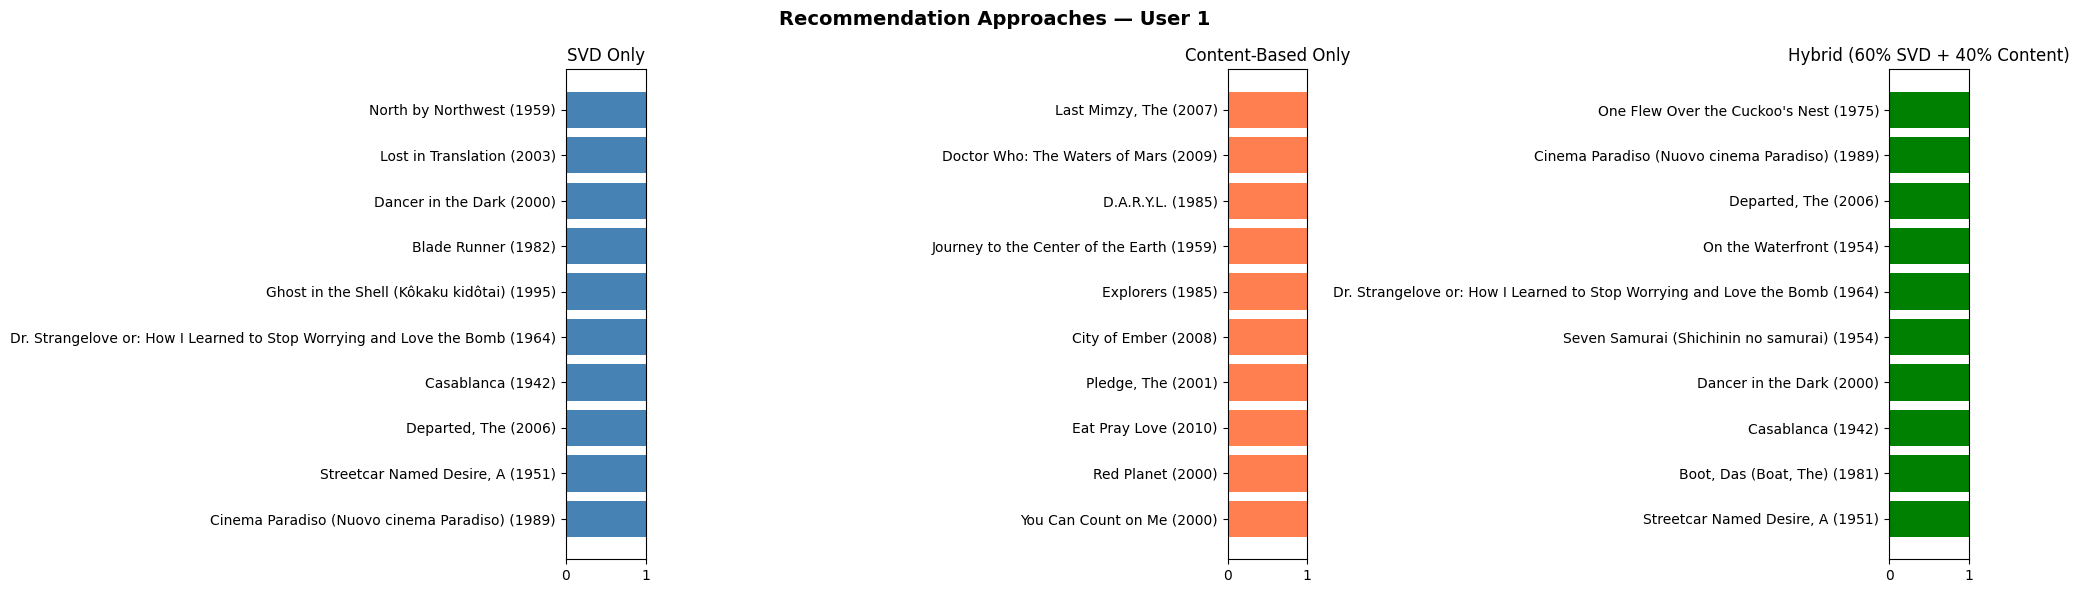

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# SVD Only
axes[0].barh(svd_only['title'].head(10),
             svd_only['collab_score'].head(10), color='steelblue')
axes[0].set_title("SVD Only")
axes[0].set_xlim(0, 1)
axes[0].invert_yaxis()

# Content Only
axes[1].barh(content_only['title'].head(10),
             content_only['content_score'].head(10), color='coral')
axes[1].set_title("Content-Based Only")
axes[1].set_xlim(0, 1)
axes[1].invert_yaxis()

# Hybrid
axes[2].barh(hybrid_recs['title'],
             hybrid_recs['hybrid_score'], color='green')
axes[2].set_title("Hybrid (60% SVD + 40% Content)")
axes[2].set_xlim(0, 1)
axes[2].invert_yaxis()

plt.suptitle("Recommendation Approaches — User 1", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [23]:
weight_combos = [
    (1.0, 0.0),   # Pure collaborative
    (0.7, 0.3),   # Heavy collaborative
    (0.6, 0.4),   # Our default
    (0.3, 0.7),   # Heavy content
    (0.0, 1.0),   # Pure content
]

print("How weights affect top recommendation:\n")
print(f"{'Collab':>8} {'Content':>8}  {'Top Recommendation'}")
print("-" * 65)

for cw, ctw in weight_combos:
    recs = get_hybrid_recommendations(
        user_id        = 1,
        movies_df      = movies,
        ratings_df     = ratings,
        svd_model      = svd_model,
        cosine_sim     = cosine_sim,
        movie_indices  = movie_indices,
        collab_weight  = cw,
        content_weight = ctw,
        n              = 1
    )
    top = recs.iloc[0]['title']
    print(f"{cw:>8.1f} {ctw:>8.1f}  {top}")

How weights affect top recommendation:

  Collab  Content  Top Recommendation
-----------------------------------------------------------------
     1.0      0.0  North by Northwest (1959)
     0.7      0.3  Cinema Paradiso (Nuovo cinema Paradiso) (1989)
     0.6      0.4  One Flew Over the Cuckoo's Nest (1975)
     0.3      0.7  Casablanca (1942)
     0.0      1.0  Last Mimzy, The (2007)


In [24]:
import json

hybrid_config = {
    "collab_weight"   : 0.6,
    "content_weight"  : 0.4,
    "rating_threshold": 4.0,
    "top_n"           : 10
}

with open("../../backend/saved_models/hybrid_config.json", "w") as f:
    json.dump(hybrid_config, f, indent=2)

print("Hybrid config saved ✅")
print(json.dumps(hybrid_config, indent=2))

Hybrid config saved ✅
{
  "collab_weight": 0.6,
  "content_weight": 0.4,
  "rating_threshold": 4.0,
  "top_n": 10
}


In [26]:
import os

saved_path = "../../backend/saved_models/"
files = os.listdir(saved_path)

print("Files in backend/saved_models/:\n")
for f in sorted(files):
    size = os.path.getsize(saved_path + f)
    print(f"  {f:35s} {size/1024:.1f} KB")

Files in backend/saved_models/:

  cosine_sim.pkl                      741457.8 KB
  hybrid_config.json                  0.1 KB
  movie_indices.pkl                   703.3 KB
  svd_model.pkl                       9785.6 KB
  tfidf_matrix.pkl                    296.9 KB
